In [9]:
import geopandas as gpd
from pathlib import Path

TRACK_ID = 129
TRACK_STR = f"{TRACK_ID:04d}"

PROC_DIR = Path(r"C:\coding\arctic\paper1\Notebook\ice-beam\Data\processed")
raw_fp   = PROC_DIR / f"dataset_raw_track_{TRACK_STR}.gpkg"
shore_fp = PROC_DIR / "shoreline.gpkg"

dataset_raw   = gpd.read_file(raw_fp, layer=f"atl06_track_{TRACK_STR}")
shoreline_gdf = gpd.read_file(shore_fp, layer="shoreline")


In [10]:
import sys
from pathlib import Path

# Repo root = folder that contains "src"
REPO_ROOT = Path(r"C:\coding\arctic\paper1\Notebook\ice-beam").resolve()
SRC_DIR = (REPO_ROOT / "src").resolve()

if not SRC_DIR.exists():
    raise FileNotFoundError(f"src folder not found at: {SRC_DIR}")

# Add src to Python path (so `import is2retreat` works)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("✅ Using SRC_DIR:", SRC_DIR)
print("✅ sys.path[0]:", sys.path[0])


✅ Using SRC_DIR: C:\coding\arctic\paper1\Notebook\ice-beam\src
✅ sys.path[0]: C:\coding\arctic\paper1\Notebook\ice-beam\src


In [11]:
import pandas as pd
import geopandas as gpd

from is2retreat.config import Params
from is2retreat.pipeline import run_workflow


In [12]:
P = Params()
P.CLUSTER_DISTANCE_M = 18
P.BIAS_TOLERANCE = 0.5
P.BIAS_X0 = 550.0
P.MIN_BEAMS = 2
P.ANGLE_SEARCH_RADIUS = 10.0
P.HALF_ALONG_M = 300
P.HALF_ACROSS_M = 300
P


Params(ORIGINAL_CRS='EPSG:4326', UTM_EPSG=32606, CLUSTER_DISTANCE_M=18, MIN_BEAMS=2, ANGLE_SEARCH_RADIUS=10.0, VERTICAL_TOLERANCE=5.0, BIAS_TOLERANCE=0.5, BIAS_X0=550.0, MIN_PROFILES_PER_CLUSTER=2, MIN_POINTS_PCT=0.8, HALF_ALONG_M=300, HALF_ACROSS_M=300, N_CYCLES=24, ELEV_TRASH=20.0, TOO_FAR_BEAM=46.0, GTX=('gt1', 'gt2', 'gt3'), GAP_THRESHOLD_M=40.0, CROSSING_ATOL=0.001, CONFIDENCE=0.95, MIN_SPAN_DAYS=365)

In [13]:
TRACK_ID = 129  # example

(
    summary_fam,
    summary_clust,
    dataset_clean,
    clusters_gdf,
    selected_clusters,
    filtered_profiles,
    bias_summary,
    bias_df,
) = run_workflow(
    track_id=TRACK_ID,
    dataset_raw=dataset_raw,
    shoreline_gdf=shoreline_gdf,
    params=P,
    verbose=True,
)


[OK] gt1: box built with 998 clipped points. nearest_beam=gt1r
[OK] gt2: box built with 897 clipped points. nearest_beam=gt2r
[OK] gt3: box built with 886 clipped points. nearest_beam=gt3r
✅ Bias filtering: kept 2 non-reference cycles (+ all baseline cycles).


In [14]:
summary_fam
selected_clusters[["gt_family","cluster_id","num_beams","angle_deg","center_lat","center_lon"]].head()
bias_summary.head()
filtered_profiles.head(20)


,track_id,gt_family,beam_id,acq_date,h_li,distance_from_offshore,alongtrack_distance,geometry,cluster_id,accepted_Bias,bias_550,keep
0,0129,gt1,gt1l,2022-12-29,-2.037826,280.314870,280.314870,POINT (-153.89121 70.88274),10,True,0.0,True
1,0129,gt1,gt1l,2022-12-29,-1.981290,300.337397,300.337397,POINT (-153.89113 70.88256),10,True,0.0,True
2,0129,gt1,gt1l,2022-12-29,-2.010303,320.359954,320.359954,POINT (-153.89106 70.88239),10,True,0.0,True
3,0129,gt1,gt1l,2022-12-29,-2.080560,340.382667,340.382667,POINT (-153.89099 70.88221),10,True,0.0,True
4,0129,gt1,gt1l,2022-12-29,-2.041935,360.405414,360.405414,POINT (-153.89091 70.88203),10,True,0.0,True
5,0129,gt1,gt1l,2022-12-29,-2.020623,380.428097,380.428097,POINT (-153.89084 70.88185),10,True,0.0,True
6,0129,gt1,gt1l,2022-12-29,-2.049832,400.450689,400.450689,POINT (-153.89077 70.88168),10,True,0.0,True
7,0129,gt1,gt1l,2022-12-29,-2.068372,420.473122,420.473122,POINT (-153.8907 70.8815),10,True,0.0,True
8,0129,gt1,gt1l,2022-12-29,-2.080301,440.495624,440.495624,POINT (-153.89063 70.88132),10,True,0.0,True
9,0129,gt1,gt1l,2022-12-29,-2.086897,460.518199,460.518199,POINT (-153.89056 70.88114),10,True,0.0,True


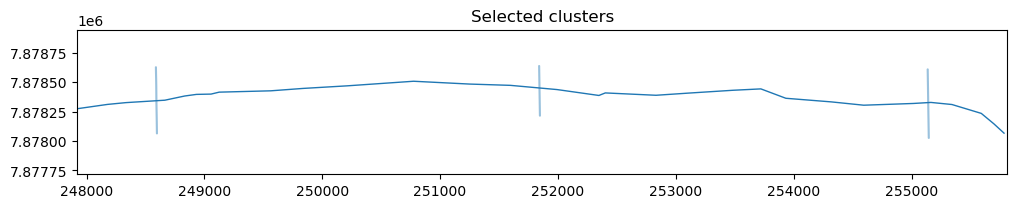

In [15]:
import matplotlib.pyplot as plt

# --------------------------------------------
# Pick a family to zoom (None = all)
# --------------------------------------------
gt_family = None   # try: "gt1" or "gt2" or "gt3"

# --------------------------------------------
# Harmonize CRS (plot in clusters CRS)
# --------------------------------------------
shore = shoreline_gdf.to_crs(clusters_gdf.crs)
clu   = clusters_gdf.copy()
sel   = selected_clusters.copy()

if gt_family is not None:
    clu = clu[clu["gt_family"] == gt_family].copy()
    sel = sel[sel["gt_family"] == gt_family].copy()

# # (optional) beam centerlines
# beam = None
# if "beam_gdf" in globals() and beam_gdf is not None and not beam_gdf.empty:
#     beam = beam_gdf.to_crs(clusters_gdf.crs)
#     if gt_family is not None and "gt_family" in beam.columns:
#         beam = beam[beam["gt_family"] == gt_family].copy()

# --------------------------------------------
# Plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

# shoreline
shore.plot(ax=ax, linewidth=1)

# all clusters (faint)
# if clu is not None and not clu.empty:
#     clu.plot(ax=ax, alpha=0.15, linewidth=0.5)

# selected clusters (highlight)
if sel is not None and not sel.empty:
    sel.plot(ax=ax, alpha=0.45, linewidth=2)

# beam lines (optional)
# if beam is not None and not beam.empty:
#     beam.plot(ax=ax, linewidth=1)

ax.set_title(f"Selected clusters" + (f" ({gt_family})" if gt_family else ""))
ax.set_aspect("equal")

# --------------------------------------------
# Zoom to selected clusters (with padding)
# --------------------------------------------
if sel is not None and not sel.empty:
    minx, miny, maxx, maxy = sel.total_bounds
    w = maxx - minx
    h = maxy - miny

    pad_frac = 0.10
    min_pad  = 300  # meters (works well in UTM)

    pad_x = max(min_pad, w * pad_frac)
    pad_y = max(min_pad, h * pad_frac)

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

plt.show()


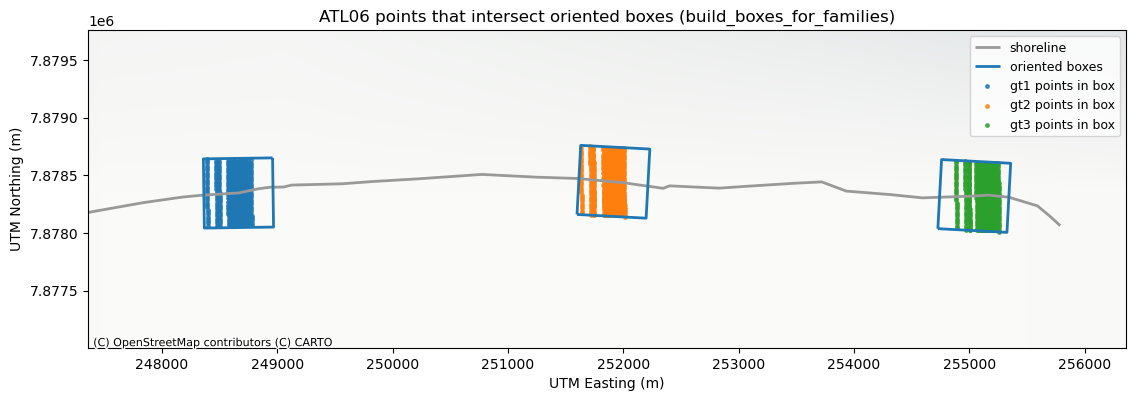

In [21]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# --- inputs you already have ---
# dataset_clean : dict from build_boxes_for_families (contains ["box"] per gt_family)
# dataset_raw   : all ATL06 points (EPSG:4326) with gt_family, beam_id, acq_date, geometry
# shoreline_path = r"C:\coding\arctic\paper1\Notebook\ice-beam\Data\coastline\NSB_AK.shp"

shoreline_path = r"C:\coding\arctic\paper1\Notebook\ice-beam\Data\coastline\NSB_AK.shp"

# Use your Params if you have it
utm_epsg = params.UTM_EPSG if "params" in globals() else 32606
target_crs = f"EPSG:{utm_epsg}"

# 1) Collect boxes into one GDF
boxes_list = []
for fam, content in dataset_clean.items():
    box = content.get("box", None)
    if box is None or len(box) == 0:
        continue
    b = box.copy()
    b["gt_family"] = str(fam)
    boxes_list.append(b)

boxes_gdf = gpd.GeoDataFrame(pd.concat(boxes_list, ignore_index=True), crs=boxes_list[0].crs if boxes_list else target_crs)
boxes_gdf = boxes_gdf.to_crs(target_crs)

# 2) Prepare points (ALL raw points, then subset by family)
pts = dataset_raw.copy()
pts["gt_family"] = pts["gt_family"].astype(str).str.strip()
pts["beam_id"]   = pts["beam_id"].astype(str).str.strip()
pts["acq_date"]  = pd.to_datetime(pts["acq_date"], errors="coerce")

pts_utm = pts.to_crs(target_crs)

# 3) Spatial join: which points fall inside which box?
# (predicate="within" is strict; "intersects" is often safer if box edges matter)
join = gpd.sjoin(
    pts_utm,
    boxes_gdf[["gt_family", "geometry"]].rename(columns={"gt_family":"box_family"}),
    how="inner",
    predicate="intersects"
).drop(columns=["index_right"])

# # 4) Quick sanity checks
# print("=== BOX SUMMARY ===")
# print(boxes_gdf[["gt_family"]].value_counts().sort_index())

# print("\n=== POINTS INSIDE BOXES (by family) ===")
# print(join.groupby("box_family").size().sort_values(ascending=False))

# print("\n=== POINTS INSIDE BOXES (by family + beam_id) ===")
# print(join.groupby(["box_family","beam_id"]).size().sort_values(ascending=False).head(20))

# print("\n=== UNIQUE CYCLES INSIDE BOXES (by family + beam_id) ===")
# tmp = join.dropna(subset=["acq_date"]).copy()
# tmp["cycle_date"] = tmp["acq_date"].dt.normalize()
# print(tmp.groupby(["box_family","beam_id"])["cycle_date"].nunique().sort_values(ascending=False).head(20))

# 5) Plot: shoreline + boxes + points inside boxes
shore = gpd.read_file(shoreline_path).to_crs(target_crs)

fig, ax = plt.subplots(figsize=(14, 4))

# shoreline context
shore.plot(ax=ax, color="0.6", linewidth=2, label="shoreline")

# boxes
boxes_gdf.boundary.plot(ax=ax, linewidth=2, label="oriented boxes")

# points inside boxes (color by box family)
for fam, g in join.groupby("box_family"):
    g.plot(ax=ax, markersize=6, alpha=0.8, label=f"{fam} points in box")

# basemap (optional)
ctx.add_basemap(ax, crs=target_crs, source=ctx.providers.CartoDB.Positron)

ax.set_title("ATL06 points that intersect oriented boxes (build_boxes_for_families)")
ax.set_xlabel("UTM Easting (m)")
ax.set_ylabel("UTM Northing (m)")
ax.legend(loc="upper right", ncol=1, fontsize=9)
plt.tight_layout()

# --- AUTO ZOOM to boxes (with padding in meters) ---
pad_m = 1000  # tweak: 1000–10000 depending on how tight you want it

minx, miny, maxx, maxy = boxes_gdf.total_bounds
ax.set_xlim(minx - pad_m, maxx + pad_m)
ax.set_ylim(miny - pad_m, maxy + pad_m)

plt.show()


Selected clusters rows: 1
All clusters rows: 7


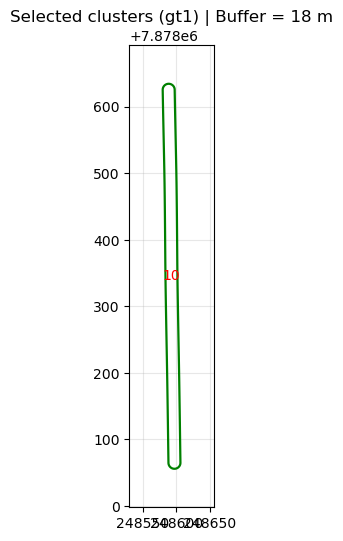

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Choose family (None = all)
# ----------------------------
gt_family = "gt1"   # None, "gt1", "gt2", "gt3"

# ----------------------------
# Safety: normalize gt_family strings
# ----------------------------
sc = selected_clusters.copy()
cg = clusters_gdf.copy() if "clusters_gdf" in globals() and clusters_gdf is not None else None
sh = shoreline_gdf.copy()

sc["gt_family"] = sc["gt_family"].astype(str).str.strip().str.lower()
if cg is not None and "gt_family" in cg.columns:
    cg["gt_family"] = cg["gt_family"].astype(str).str.strip().str.lower()

# ----------------------------
# Filter by family
# ----------------------------
if gt_family is not None:
    fam = str(gt_family).strip().lower()
    sc = sc.loc[sc["gt_family"] == fam].copy()
    if cg is not None:
        cg = cg.loc[cg["gt_family"] == fam].copy()

print("Selected clusters rows:", len(sc))
if cg is not None:
    print("All clusters rows:", len(cg))

if sc.empty:
    raise ValueError("No selected clusters for this gt_family. Check values with: selected_clusters['gt_family'].unique()")

# ----------------------------
# CRS alignment
# ----------------------------
# Work in the CRS of selected_clusters
target_crs = sc.crs
if target_crs is None:
    raise ValueError("selected_clusters has no CRS. Set it before plotting.")

if sh.crs != target_crs:
    sh = sh.to_crs(target_crs)

if cg is not None and cg.crs != target_crs:
    cg = cg.to_crs(target_crs)

# ----------------------------
# Compute zoom bounds from selected clusters
# ----------------------------
minx, miny, maxx, maxy = sc.total_bounds
dx = maxx - minx
dy = maxy - miny

# padding (10% of width/height, with a small minimum)
padx = max(dx * 0.10, 50)
pady = max(dy * 0.10, 50)

xmin, xmax = minx - padx, maxx + padx
ymin, ymax = miny - pady, maxy + pady

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# shoreline
sh.plot(ax=ax, color="none", edgecolor="blue", linewidth=1.5, zorder=1)

# all clusters (optional background)
# if cg is not None and not cg.empty:
#     cg.boundary.plot(ax=ax, color="0.7", linewidth=0.8, zorder=2)

# selected clusters (IMPORTANT: boundary only, no fill -> avoids the "blob")
sc.boundary.plot(ax=ax, color="green", linewidth=1.6, zorder=3)

# labels (cluster_id) at centroid
cent = sc.geometry.centroid
for cid, x, y in zip(sc["cluster_id"].tolist(), cent.x.tolist(), cent.y.tolist()):
    ax.text(x, y, str(cid), color="red", fontsize=10, ha="center", va="center", zorder=4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(f"Selected clusters ({gt_family if gt_family else 'all'}) | Buffer = {float(P.CLUSTER_DISTANCE_M):g} m")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

plt.show()


In [ ]:
fam = "gt1"
print("clusters gt1:", len(clusters_gdf.query("gt_family == @fam")))
print("selected gt1:", len(selected_clusters.query("gt_family == @fam")))


clusters gt1: 7
selected gt1: 1


In [ ]:
clusters_gdf.query("gt_family == 'gt1'")["num_beams"].describe()


count    7.0
mean     2.0
std      0.0
min      2.0
25%      2.0
50%      2.0
75%      2.0
max      2.0
Name: num_beams, dtype: float64

In [ ]:
# This is (gt_family, beam_id) tuples; count unique beam IDs
gt1 = clusters_gdf.query("gt_family == 'gt1'")
unique_beams = set()
for lst in gt1["beam_ids"]:
    for fb in lst:
        unique_beams.add(fb)
print("unique beams in gt1:", len(unique_beams))


unique beams in gt1: 2


In [ ]:
sel = selected_clusters.query("gt_family == 'gt1'").iloc[0]
print("selected cluster num_beams:", sel["num_beams"])
print("selected cluster beam_ids length:", len(sel["beam_ids"]))


selected cluster num_beams: 2
selected cluster beam_ids length: 2


In [ ]:
print(dataset_raw.geometry.geom_type.value_counts().head())
print(dataset_raw.columns)
print(len(dataset_raw))
print(dataset_raw.head(2))


Point    4710
Name: count, dtype: int64
Index(['track_id', 'gt_family', 'beam_id', 'acq_date', 'h_li',
       'distance_from_offshore', 'alongtrack_distance', 'geometry'],
      dtype='object')
4710
  track_id gt_family beam_id   acq_date      h_li  distance_from_offshore  \
0     0129       gt1    gt1l 2019-04-06 -2.057371                0.000000   
1     0129       gt1    gt1l 2019-04-06 -2.040180               20.022506   

   alongtrack_distance                     geometry  
0             0.000000  POINT (-153.89172 70.88525)  
1            20.022506  POINT (-153.89165 70.88508)  
